In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 固定 PyTorch 随机种子，让模型初始化和训练结果可复现
torch.manual_seed(42)

In [14]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

print(X.shape)
print(y.shape)

(500, 2)
(500,)


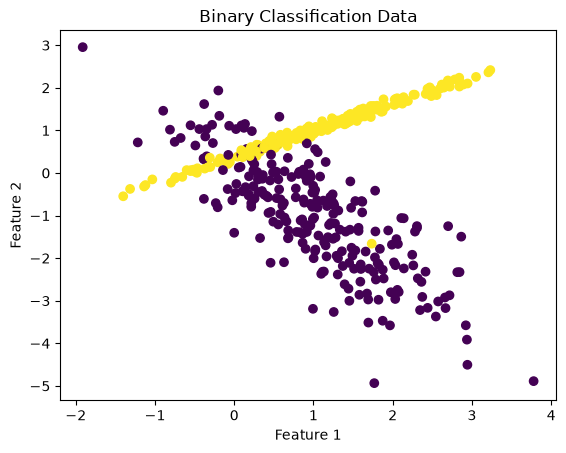

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Data")
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [19]:
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [20]:
model = BinaryClassifier()
print(model)

BinaryClassifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [21]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [22]:
for epoch in range(500):
    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"第 {epoch+1} 轮，loss = {loss.item():.4f}")

第 50 轮，loss = 0.4168
第 100 轮，loss = 0.2502
第 150 轮，loss = 0.2066
第 200 轮，loss = 0.1900
第 250 轮，loss = 0.1688
第 300 轮，loss = 0.1450
第 350 轮，loss = 0.1288
第 400 轮，loss = 0.1154
第 450 轮，loss = 0.1049
第 500 轮，loss = 0.0961


In [23]:
with torch.no_grad():
    y_prob = model(X_test)
    y_pred = (y_prob >= 0.5).float()

accuracy = (y_pred.eq(y_test).sum() / y_test.shape[0]).item()

print("测试集准确率：", accuracy)

测试集准确率： 0.9900000095367432


In [24]:
print("预测概率前 10 个：")
print(y_prob[:10])

print("预测类别前 10 个：")
print(y_pred[:10])

print("真实标签前 10 个：")
print(y_test[:10])

预测概率前 10 个：
tensor([[0.7826],
        [0.7593],
        [0.0016],
        [0.9832],
        [0.0016],
        [0.9473],
        [0.0544],
        [0.8465],
        [0.1250],
        [0.9826]])
预测类别前 10 个：
tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.]])
真实标签前 10 个：
tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.]])
